In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
#this line is for Jupyter Notebook to display the plot inline

This part is to understand derivatives

In [3]:
def f(x):
    return 3*x**2 - 4*x +5

In [4]:
f(3.0)

20.0

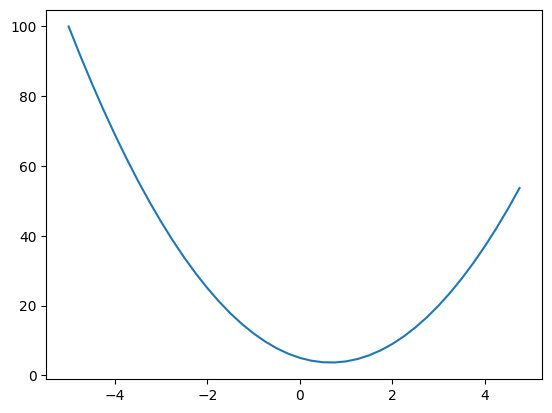

In [5]:
xs= np.arange(-5.0,5.0,0.25)
ys=f(xs)
plt.plot(xs,ys)

In [7]:
h=0.000001
x=2/3
(f(x+h)-f(x))/h

2.999378523327323e-06

Derivate is the measure of how the function changes when nudge the input a little bit.

The reason for dividing by the nudge is to make sure the change is not due to the nudge itself, but the function's response to the nudge. If we don't divide by the nudge, we would just be measuring the size of the nudge, which is not what we want. For example, if we nudge the input by 0.01 and the function changes by 0.02, we want to know how much the function changes per unit of nudge, which is 0.02 / 0.01 = 2. This tells us that for every unit of nudge, the function changes by 2 units. If we didn't divide by the nudge, we would just say the function changed by 0.02, which doesn't give us any information about how sensitive the function is to changes in the input.

In [9]:
#more complex case
a=2.0
b=-3.0
c=10
d=a*b+c
print(d)

4.0


In [ ]:
h=0.0001
# let's see how a affect the function 
a=2.0
b=-3.0
c=10
d1=a*b+c
a+=h
d2=a*b+c

print(f"d1:{d1}")
print(f"d2:{d2}")

print('slope at these point', (d2-d1)/h)

#should be b

d1:4.0
d2:3.999699999999999
slope at these point -3.000000000010772


In [11]:
h=0.0001
# let's see how b affect the function 
a=2.0
b=-3.0
c=10
d1=a*b+c
b+=h
d2=a*b+c

print(f"d1:{d1}")
print(f"d2:{d2}")

print('slope at these point', (d2-d1)/h)

#should be a

d1:4.0
d2:4.0002
slope at these point 2.0000000000042206


In [ ]:
h=0.0001
# let's see how c affect the function 
a=2.0
b=-3.0
c=10
d1=a*b+c
c+=h
d2=a*b+c

print(f"d1:{d1}")
print(f"d2:{d2}")

print('slope at these point', (d2-d1)/h)

#should be 1

d1:4.0
d2:4.0001
slope at these point 0.9999999999976694


We will write a Value class with data variable.

the children variable is a list of Value objects that are inputs to this Value and _op varible is a string that represents the final operation that produced this Value.


In [185]:
class Value:

    def __init__(self,data, _children=(), _op="", _label=""):
        self.data=data
        self.grad=0.0
        self._backward= lambda: None
        self._prev=set(_children)
        self._op=_op
        self._label=_label

    def __repr__(self):
        return f"Value(data={self.data})" #this is what returned when a value object is printed
    
    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out= Value(self.data+other.data, (self,other),"+")

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward=_backward

        return out #this will allow addition of two value objects
    
    def __radd__(self, other):
        return self + other
    
    def __sub__(self, other):
        return self+ (-other)
    
    def __mul__(self, other):
        other = other if isinstance(other,Value) else Value(other)

        out = Value(self.data*other.data, (self,other),"*" )

        def _backward():
            self.grad+=other.data *out.grad
            other.grad+=self.data *out.grad
        out._backward=_backward    

        return out

    def __pow__(self,other):
        assert isinstance(other,(int,float))
        out=Value(self.data**other, (self,),f'**{other}')

        def _backward():
            self.grad+= other* self.data **(other-1) *out.grad

        out._backward=_backward

        return out    

    def __rmul__(self, other):
        return self*other
    
    def __truediv__(self,other):
        return self*other**(-1)
    
    def exp(self):
        x=self.data
        out=Value(math.exp(x),(self,),"exp")

        def _backward():
            self.grad+= out.data * out.grad
        out._backward=_backward

        return out    

    
    def tanh(self):
        n=self.data
        t=((math.exp(2*n)-1)/(math.exp(2*n)+1))
        out= Value(t, (self,),"tanh")

        def _backward():
            self.grad += (1-t**2)*out.grad
            
        out._backward=_backward  
        return out
    
    def backward(self):

        self.grad=1.0
        topo=[]
        visited=set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)      

        for node in reversed(topo):
            node._backward()
    

In [137]:
a+2

Value(data=4)

In [135]:
a= Value(2, _label="a")
b= Value(-3, _label="b")
c= Value(10, _label="c")
e=a*b;e._label="e"

d=e+c; d._label="d"
d

f=Value(-2.0, _label="f")

L=d*f; L._label="L"

In [57]:
d._prev
d._op

'+'

In [121]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid= str(id(n))
        dot.node(name=uid, label="{%s|data %.4f| grad %.4f}" % (n._label, n.data, n.grad), shape='record')

        if n._op:
            dot.node(name =uid + n._op, label=n._op)
            dot.edge(uid+ n._op, uid )
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+ n2._op)
    return dot




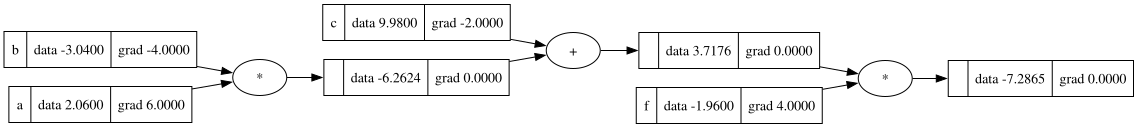

In [122]:
draw_dot(L)

We will now try to find the derivative of L with respect f,d etc. Not a,b because a and b are constants. 

Derivate of L with respect to f is what is the change in L when we nudge f a little bit.

In [62]:
#To update to make L go up

a.data+=0.01*a.grad
b.data+=0.01*b.grad
c.data+=0.01*c.grad
f.data+=0.01*f.grad

e= a*b 
d=e+c
L=d*f
# e.data+=0.01*e.grad

print(L.data)

-7.286496


In [61]:
L.grad=1.0
f.grad=4.0 # dL/df=d(d*f)/df=d
d.grad=-2.0 # dL/dd=d(d*f)/df=f

c.grad=-2.0
e.grad=-2.0

a.grad=6.0
b.grad=-4.0

dL/dc #we have to find how c affects L through d

 dd/dc= 1 d=c+e (local derivate)

 WANT:
 dL/dc

 know:
 dl/dd
 dd/dc

 dl/dc= dl/dd * dd/dc (chain rule)

 dl/de=dl/dd *dd/de
 dl/de=dl/dd *d(c+e)/de

 Want:
 dl/da

 dl/da= dl/de * de/da
 dl/da= dl/de * d(a*b)/da
 dl/da= dl/de * b



 

In [53]:
def lol():
    h=0.001
    a= Value(2, _label="a")
    b= Value(-3, _label="b")
    c= Value(10, _label="c")
    e=a*b;e._label="e"

    d=e+c; d._label="d"
    d

    f=Value(-2.0, _label="f")

    L=d*f; L._label="L"
    L1=L.data

    a= Value(2, _label="a")
    b= Value(-3+h, _label="b")
    c= Value(10, _label="c")
    e=a*b;e._label="e"

    d=e+c; d._label="d"
    d.data

    f=Value(-2.0, _label="f")

    L=d*f; L._label="L"
    L2=L.data

    print((L2-L1)/h)

lol()

-3.9999999999995595


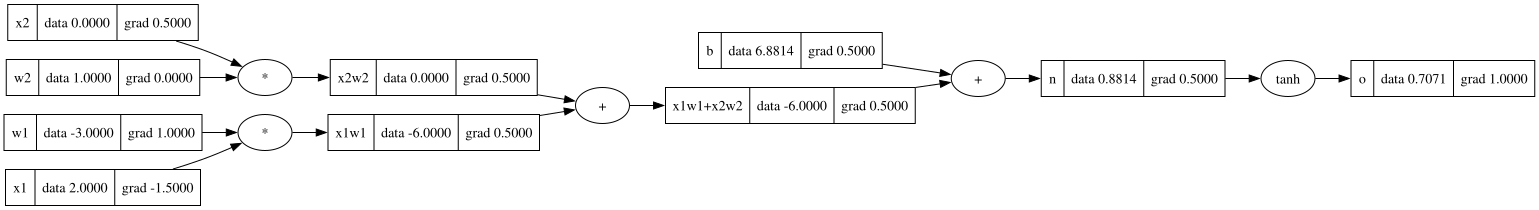

In [153]:
x1=Value(2.0, _label="x1")
x2=Value(0.0, _label="x2")
#weight w1,w2
w1=Value(-3.0, _label="w1")
w2=Value(1.0, _label="w2")
#bias
# b=Value(6.88, _label="b")
b=Value(6.8813735870195432, _label="b")

x1w1= x1*w1; x1w1._label="x1w1"
x2w2= x2*w2; x2w2._label="x2w2" 

x1w1x2w2= x1w1 + x2w2; x1w1x2w2._label="x1w1+x2w2"
n= x1w1x2w2 + b; n._label="n"

o= n.tanh(); o._label="o"



o.backward()

draw_dot(o)

Value(data=5.828427124746192)


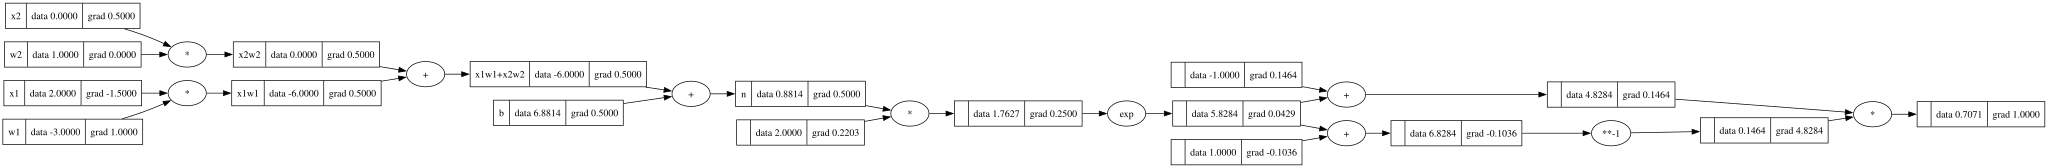

In [154]:
x1=Value(2.0, _label="x1")
x2=Value(0.0, _label="x2")
#weight w1,w2
w1=Value(-3.0, _label="w1")
w2=Value(1.0, _label="w2")
#bias
# b=Value(6.88, _label="b")
b=Value(6.8813735870195432, _label="b")

x1w1= x1*w1; x1w1._label="x1w1"
x2w2= x2*w2; x2w2._label="x2w2" 

x1w1x2w2= x1w1 + x2w2; x1w1x2w2._label="x1w1+x2w2"
n= x1w1x2w2 + b; n._label="n"

# o= n.tanh(); o._label="o"

# splitting o

e= (2*n).exp()
print(e)
o=(e-1)/(e+1)



o.backward()

draw_dot(o)


In [81]:
# o=tanh(n)
# do/dn= 1- tanh(n)**2= 1-o**2
1-o.data**2

0.4999999999999999

In [118]:
#In order to make it call _backward on it own, we need to get results of all the nodes after it. 
# So we use toplogical sort in which a DAG's edges always flow from left to right
o.grad=1.0
topo=[]
visited=set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo            

for node in reversed(topo):
    node._backward()


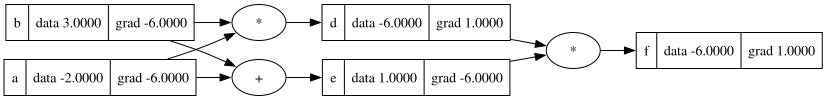

In [129]:
#There is a bug with the current setup, what if the node is used twice or more.
#  So we need to accumulate them. So instead of = we now use +=

a=Value(-2.0,_label='a')
b=Value(3.0,_label='b')
d=a*b ; d._label='d'
e=a+b ; e._label='e'
f=d*e ; f._label='f'

f.backward()

draw_dot(f)

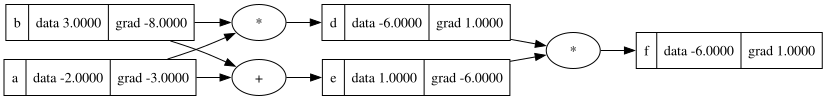

In [ ]:
#There is a bug with the current setup, what if the node is used twice or more.
#  So we need to accumulate them. So instead of = we now use +=

a=Value(-2.0,_label='a')
b=Value(3.0,_label='b')
d=a*b ; d._label='d'
e=a+b ; e._label='e'
f=d*e ; f._label='f'

f.backward()

draw_dot(f)

In [161]:
import torch

x1=torch.Tensor([2.0]).double(); x1.requires_grad = True
x2=torch.Tensor([0.0]).double(); x2.requires_grad = True
w1=torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2=torch.Tensor([1.0]).double(); w2.requires_grad = True
b=torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True

n=x1*w1 + x2*w2 + b
o=n.tanh()
o.backward()


print("---")
print(o.data.item())
print(f"x1.grad: {x1.grad}")
print(f"x2.grad: {x2.grad}")
print(f"w1.grad: {w1.grad}")
print(f"w2.grad: {w2.grad}")
print(f"b.grad: {b.grad}")


---
0.7071066904050358
x1.grad: tensor([-1.5000], dtype=torch.float64)
x2.grad: tensor([0.5000], dtype=torch.float64)
w1.grad: tensor([1.0000], dtype=torch.float64)
w2.grad: tensor([0.], dtype=torch.float64)
b.grad: tensor([0.5000], dtype=torch.float64)


In [191]:
class Neuron:
    
    def __init__(self, nin):
        self.w=[Value(np.random.uniform(-1,1)) for _ in range(nin)]
        self.b=Value(0.0)

    def __call__(self,x):
        act=sum((wi*xi for wi,xi in zip(self.w,x)), self.b)
        out=act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]    
    

class Layer: 
        def __init__(self,nin,nout):
            self.neurons= [Neuron(nin) for _ in range(nout)]

        def __call__(self,x):
            outs=[n(x) for n in self.neurons]
            return outs[0] if len(outs)==1 else outs
        
        def parameters(self):
            return [p for n in self.neurons for p in n.parameters()]
            
    
class MLP:

    def __init__(self,nin,nouts):
        sz=[nin]+nouts
        self.layers=[Layer(sz[i],sz[i+1]) for i in range(len(sz)-1)]

    def __call__(self,x):
        for layer in self.layers:
            x=layer(x)
        return x
    
    def parameter(self):
        return [p for layer in self.layers for p in layer.parameters()]

x=[2.0,3.0,-1.0]

n=MLP(3,[4,4,1])

n(x)

Value(data=-0.2375963445429794)

In [192]:
n.parameter()

[Value(data=0.3069834947105381),
 Value(data=-0.97417333947391),
 Value(data=-0.5649228242457789),
 Value(data=0.0),
 Value(data=-0.3283097749826822),
 Value(data=0.2959361910766438),
 Value(data=0.39226644364535157),
 Value(data=0.0),
 Value(data=-0.8384711414615045),
 Value(data=0.48702376064868647),
 Value(data=0.26198085847566066),
 Value(data=0.0),
 Value(data=0.71316752329676),
 Value(data=-0.9081050670067463),
 Value(data=0.3533970825028878),
 Value(data=0.0),
 Value(data=-0.7392517526445344),
 Value(data=0.3561337368505393),
 Value(data=-0.49344008294469033),
 Value(data=-0.7587342475009029),
 Value(data=0.0),
 Value(data=0.6504264856181421),
 Value(data=-0.8252090576879869),
 Value(data=-0.40223159909718853),
 Value(data=-0.8413393909137841),
 Value(data=0.0),
 Value(data=-0.8140035250225444),
 Value(data=-0.7491922378370026),
 Value(data=0.48773296902579677),
 Value(data=-0.789627696431956),
 Value(data=0.0),
 Value(data=-0.30083888748766485),
 Value(data=-0.5327193943275721)

In [ ]:
xs=[
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]

ys=[1.0, -1.0, -1.0, 1.0]



[Value(data=-0.2375963445429794),
 Value(data=-0.30166000717515834),
 Value(data=0.36941356581783363),
 Value(data=-0.384536380292015)]

In [235]:
ypred=[n(x) for x in xs]
ypred

[Value(data=0.9960105374644882),
 Value(data=-0.9782642508061219),
 Value(data=-0.9996109942266671),
 Value(data=0.9970113695064281)]

In [230]:
loss= sum((yout - ygt)**2 for yout, ygt in zip(ypred, ys))
loss

Value(data=6.724524303494592)

In [231]:
loss.backward()

In [232]:
n.layers[0].neurons[0].w[0].grad

1.8656801382000758

In [233]:
n.layers[0].neurons[0].w[0].data

-0.11350815369522615

In [234]:
for p in n.parameter():
    p.data += -0.1*p.grad

In [237]:
#Gradient descent

for k in range (20):
    # forward
    ypred=[n(x) for x in xs]
    loss=sum((yout -ygt)**2 for yout,ygt in zip(ypred,ys))

    #backward
    for p in n.parameter():
        p.grad=0.0
    loss.backward()

    # update
    for p in n.parameter():
        p.data+=-0.05*p.grad

    print(k,loss.data)    



0 0.0004974418420602191
1 0.0004900030098365938
2 0.00048277471901813496
3 0.0004757483864210384
4 0.0004689158815391213
5 0.00046226949742248755
6 0.0004558019237575034
7 0.00044950622195754036
8 0.0004433758020926207
9 0.00043740440150236604
10 0.00043158606495151934
11 0.0004259151262006895
12 0.00042038619087656913
13 0.00041499412053658973
14 0.00040973401783271
15 0.00040460121268718073
16 0.0003995912494013874
17 0.0003946998746253461
18 0.0003899230261220884
19 0.0003852568222666682


In [238]:
ypred

[Value(data=0.9962319608742092),
 Value(data=-0.9809515662126),
 Value(data=-0.9996140376258357),
 Value(data=0.9971597699554531)]